# RRN

El dataset contiene mini-mensajes en inglés con seis emociones: anger, fear, joy, love, sadness y surprise ([Kaggle][2]).

Uso `tiktoken.encoding_for_model("gpt2")` con mapeo a la codificación `gpt2` según `tiktoken` ([GitHub][1]).


**M Rivera**

mayo 2026


In [ ]:
#!pip install tiktoken kagglehub

In [ ]:
import os
import glob
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score
import tiktoken
import kagglehub

## 1. Descargar dataset de Kaggle

In [ ]:
path = kagglehub.dataset_download("parulpandey/emotion-dataset")
print("Dataset path:", path)

csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print(csv_files)

# Usualmente el dataset trae train.csv, validation.csv y test.csv
train_df = pd.read_csv([f for f in csv_files if "train" in f.lower()][0])
val_df   = pd.read_csv([f for f in csv_files if "validation" in f.lower()][0])
test_df  = pd.read_csv([f for f in csv_files if "test" in f.lower()][0])

print(train_df.head())

Using Colab cache for faster access to the 'emotion-dataset' dataset.
Dataset path: /kaggle/input/emotion-dataset
['/kaggle/input/emotion-dataset/validation.csv', '/kaggle/input/emotion-dataset/training.csv', '/kaggle/input/emotion-dataset/test.csv']
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


## 2. Tokenizador tiktoken con codificación GPT-2

In [ ]:
enc = tiktoken.encoding_for_model("gpt2")
vocab_size = enc.n_vocab
print("GPT-2 vocab size:", vocab_size)

MAX_LEN = 64

def encode_text(text, max_len=MAX_LEN):
    ids = enc.encode(str(text))
    ids = ids[:max_len]
    attention_len = len(ids)

    # padding con 0
    ids = ids + [0] * (max_len - len(ids))
    return ids, attention_len


GPT-2 vocab size: 50257


## 3. Dataset para PyTorch

In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids, length = encode_text(self.texts[idx])

        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

batch_size = 64

train_loader = DataLoader(  EmotionDataset(train_df),
                            batch_size=batch_size,
                            shuffle=True)
val_loader   = DataLoader(  EmotionDataset(val_df),
                            batch_size=batch_size,
                            shuffle=False)
test_loader  = DataLoader( EmotionDataset(test_df),
                            batch_size=batch_size,
                            shuffle=False)

## 4. Modelo recurrente: Embedding + BiLSTM + Clasificador

In [ ]:
class RNNEmotionClassifier(nn.Module):
    def __init__(self,
                 vocab_size,
                 embed_dim   = 128,
                 hidden_dim  = 128,
                 num_layers  = 2,
                 num_classes = 6,
                 dropout     = 0.3
                ):
        super().__init__()

        self.embedding = nn.Embedding(  num_embeddings= vocab_size,
                                        embedding_dim = embed_dim,
                                        padding_idx   = 0
                                    )
        self.rnn = nn.LSTM(input_size     = embed_dim,
                            hidden_size   = hidden_dim,
                            num_layers    = num_layers,
                            batch_first   = True,
                            bidirectional = True,
                            dropout       =dropout
                        )
        self.classifier = nn.Sequential(nn.Dropout(dropout),
                                        nn.Linear(hidden_dim * 2, num_classes)
                                    )

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)

        packed = nn.utils.rnn.pack_padded_sequence(
                                        x,
                                        lengths.cpu(),
                                        batch_first=True,
                                        enforce_sorted=False
                                    )

        _, (h_n, _) = self.rnn(packed)

        # Última capa: dirección forward y backward
        h_forward = h_n[-2]
        h_backward = h_n[-1]

        h = torch.cat([h_forward, h_backward], dim=1)

        logits = self.classifier(h)
        return logits

## 5. Entrenamiento

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = RNNEmotionClassifier(vocab_size=vocab_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0
    y_true = []
    y_pred = []

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(y_true, y_pred)

    return avg_loss, acc


epochs = 10
best_val_acc = 0.0

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_rnn_emotion_model.pt")

Device: cuda
Epoch 01 | Train Loss: 1.3650 | Train Acc: 0.4689 | Val Loss: 1.0166 | Val Acc: 0.6560
Epoch 02 | Train Loss: 0.6259 | Train Acc: 0.7846 | Val Loss: 0.5204 | Val Acc: 0.8185
Epoch 03 | Train Loss: 0.3365 | Train Acc: 0.8851 | Val Loss: 0.4183 | Val Acc: 0.8605
Epoch 04 | Train Loss: 0.2074 | Train Acc: 0.9265 | Val Loss: 0.3401 | Val Acc: 0.8835
Epoch 05 | Train Loss: 0.1360 | Train Acc: 0.9503 | Val Loss: 0.3601 | Val Acc: 0.8950
Epoch 06 | Train Loss: 0.0921 | Train Acc: 0.9660 | Val Loss: 0.4074 | Val Acc: 0.8910
Epoch 07 | Train Loss: 0.0703 | Train Acc: 0.9747 | Val Loss: 0.3559 | Val Acc: 0.9010
Epoch 08 | Train Loss: 0.0502 | Train Acc: 0.9816 | Val Loss: 0.4470 | Val Acc: 0.8955
Epoch 09 | Train Loss: 0.0409 | Train Acc: 0.9851 | Val Loss: 0.3879 | Val Acc: 0.9015
Epoch 10 | Train Loss: 0.0301 | Train Acc: 0.9902 | Val Loss: 0.4325 | Val Acc: 0.9085


## 6. Evaluación final

In [ ]:
model.load_state_dict(torch.load("best_rnn_emotion_model.pt"))
model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        labels = batch["label"].to(device)

        logits = model(input_ids, lengths)
        preds = torch.argmax(logits, dim=1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())


label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

print("Test accuracy:", accuracy_score(all_true, all_pred))
print(classification_report(all_true, all_pred, target_names=label_names))


Test accuracy: 0.9045
              precision    recall  f1-score   support

     sadness       0.95      0.95      0.95       581
         joy       0.93      0.91      0.92       695
        love       0.79      0.82      0.80       159
       anger       0.89      0.91      0.90       275
        fear       0.84      0.90      0.87       224
    surprise       0.80      0.68      0.74        66

    accuracy                           0.90      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.91      0.90      0.90      2000



## 7. Función de inferencia

In [ ]:
def predict_emotion(text):
    model.eval()

    ids, length = encode_text(text)
    input_ids = torch.tensor([ids], dtype=torch.long).to(device)
    lengths = torch.tensor([length], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_ids, lengths)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return label_names[pred], probs.cpu().numpy()[0]


texto = "I am so happy today!"
emotion, probs = predict_emotion(texto)

print("Texto:", texto)
print("Emoción predicha:", emotion)
print("Probabilidades:", probs)

Texto: I am so happy today!
Emoción predicha: joy
Probabilidades: [3.6306074e-04 9.9912828e-01 8.4775980e-05 2.3419232e-04 1.5798157e-04
 3.1825999e-05]


## 8. Matriz de confusión

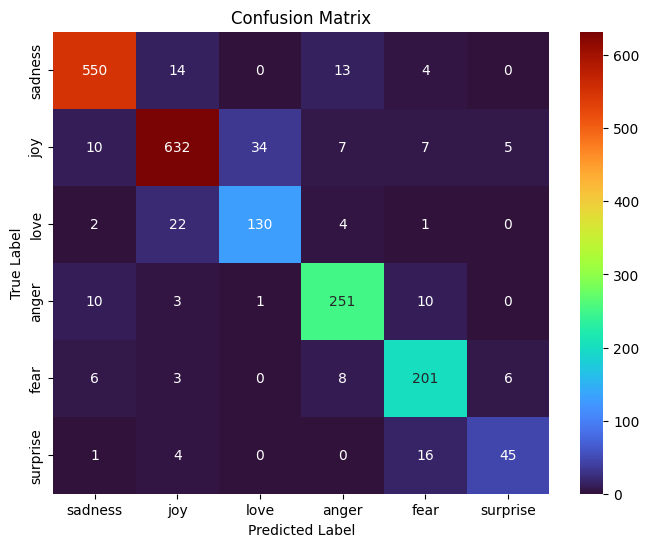

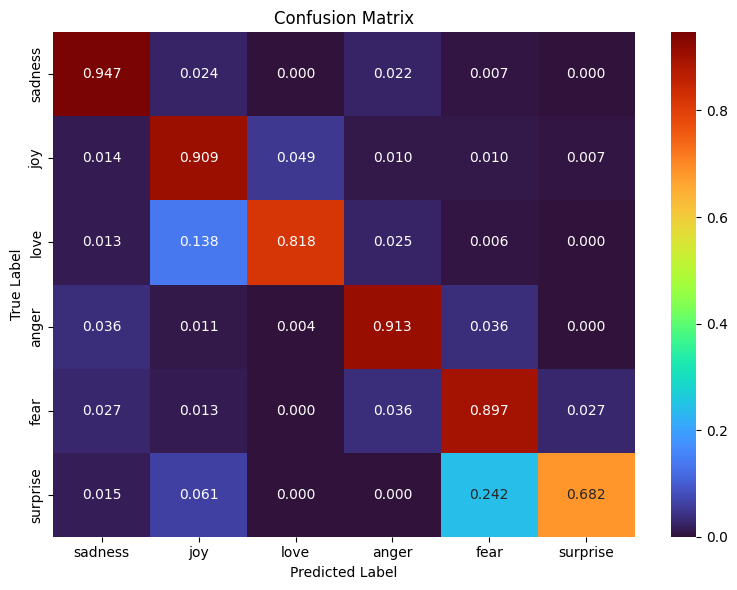

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# calcular matriz de confusión
cm = confusion_matrix(all_true, all_pred)

# nombres de clases
label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

# figura
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="turbo",
            xticklabels=label_names,
            yticklabels=label_names
            )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")


# clases normalizadas
cm=cm/cm.sum(axis=1, keepdims=True)
# figura
plt.figure(figsize=(8, 6))

sns.heatmap(cm,
            annot=True,
            fmt=".3f",
            cmap="turbo",
            xticklabels=label_names,
            yticklabels=label_names
            )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

---

# Parte II — Comparación de arquitecturas recurrentes

A partir del modelo BiLSTM anterior, se implementan tres modelos adicionales basados en redes recurrentes para clasificar la emoción de cada mini-mensaje:

- **(a) SimpleRNN** — una capa `nn.RNN` (tanh) bidireccional.
- **(b) GatedRNN** — una capa `nn.GRU` bidireccional.
- **(c) Variante** — el **BiLSTM** del notebook (`nn.LSTM` bidireccional), tomado como variante de los modelos básicos.

**Protocolo experimental.** Cada modelo se entrena **10 veces** usando los conjuntos de entrenamiento, validación y test **fijos** que provienen de los tres archivos del dataset (`train.csv`, `validation.csv`, `test.csv`). La única fuente de aleatoriedad entre repeticiones es la **semilla**, que controla la inicialización de los pesos y el orden de los lotes de entrenamiento. De cada repetición se guarda el desempeño en test: *accuracy, precision, recall* y *F1-score* (macro-promediadas sobre las 6 clases). Finalmente se reporta el **promedio** y la **varianza** de cada métrica, una tabla comparativa, y un análisis de significancia estadística.

> Nota: como la partición es fija, la varianza observada mide la **robustez del modelo a la inicialización y al orden de los datos**, no a la partición. Por ello las comparaciones entre modelos se hacen de forma **pareada por semilla** (sección 14).

## 9. Utilidades comunes (loaders fijos y métricas)

In [ ]:
import numpy as np
import random
from sklearn.metrics import precision_recall_fscore_support

NUM_CLASSES = 6
label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_loaders(seed, batch_size=64):
    """Loaders con la particion FIJA de los archivos del dataset.

    Solo el orden del train_loader depende de la semilla (shuffle);
    val y test son deterministas.
    """
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(EmotionDataset(train_df), batch_size=batch_size,
                              shuffle=True, generator=g)
    val_loader   = DataLoader(EmotionDataset(val_df),   batch_size=batch_size,
                              shuffle=False)
    test_loader  = DataLoader(EmotionDataset(test_df),  batch_size=batch_size,
                              shuffle=False)
    return train_loader, val_loader, test_loader


def evaluate(model, loader):
    """Devuelve accuracy, precision, recall, f1 (todas macro) sobre un loader."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            lengths   = batch["length"].to(device)
            labels    = batch["label"].to(device)

            logits = model(input_ids, lengths)
            preds  = torch.argmax(logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


## 10. Definición de las tres arquitecturas

In [ ]:
class SimpleRNNClassifier(nn.Module):
    """(a) Una capa nn.RNN (tanh) bidireccional + clasificador."""
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=2, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, nonlinearity="tanh",
                          batch_first=True, bidirectional=True, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.rnn(packed)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.classifier(h)


class GatedRNNClassifier(nn.Module):
    """(b) Una capa nn.GRU bidireccional + clasificador."""
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=2, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(input_size=embed_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True,
                          bidirectional=True, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.rnn(packed)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.classifier(h)


class LSTMClassifier(nn.Module):
    """(c) Variante: el BiLSTM del notebook (nn.LSTM bidireccional).

    Identica en estructura a RNNEmotionClassifier de la Parte I; se reescribe
    aqui con la misma firma que los otros dos modelos para el bucle experimental.
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=2, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           bidirectional=True, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.rnn(packed)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.classifier(h)


## 11. Bucle experimental: 10 repeticiones por modelo

Cada repetición usa una semilla distinta (`1000..1009`) que controla la inicialización de los pesos y el orden de los lotes de entrenamiento. La partición train/val/test es la **fija** de los archivos.

Se conserva el criterio del notebook original: nos quedamos con los pesos que dan la mejor *accuracy* de validación y con ellos se evalúa el test.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

N_REPEATS = 10
EPOCHS    = 10

MODELS = {
    "SimpleRNN": SimpleRNNClassifier,
    "GatedRNN (GRU)": GatedRNNClassifier,
    "LSTM (variante)": LSTMClassifier,
}


def train_one_run(ModelClass, seed):
    """Entrena un modelo una vez con la semilla dada; devuelve metricas de test."""
    set_seed(seed)
    train_loader, val_loader, test_loader = make_loaders(seed=seed)

    model = ModelClass(vocab_size=vocab_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        # --- train ---
        model.train()
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            lengths   = batch["length"].to(device)
            labels    = batch["label"].to(device)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # --- validacion ---
        val_metrics = evaluate(model, val_loader)
        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Restaurar mejores pesos y evaluar en test.
    model.load_state_dict(best_state)
    return evaluate(model, test_loader)


# Almacen de resultados: results[model_name] = lista de dicts de metricas
results = {name: [] for name in MODELS}

for name, ModelClass in MODELS.items():
    print(f"\n========== {name} ==========")
    for r in range(N_REPEATS):
        seed = 1000 + r
        m = train_one_run(ModelClass, seed=seed)
        results[name].append(m)
        print(f"  run {r+1:02d} (seed={seed}) | "
              f"acc={m['accuracy']:.4f}  prec={m['precision']:.4f}  "
              f"rec={m['recall']:.4f}  f1={m['f1']:.4f}")


Device: cuda

========== SimpleRNN ==========
  run 01 (seed=1000) | acc=0.8390  prec=0.7811  rec=0.7924  f1=0.7841
  run 02 (seed=1001) | acc=0.8270  prec=0.7393  rec=0.7365  f1=0.7361
  run 03 (seed=1002) | acc=0.8360  prec=0.7672  rec=0.7497  f1=0.7559
  run 04 (seed=1003) | acc=0.8450  prec=0.8017  rec=0.7473  f1=0.7670
  run 05 (seed=1004) | acc=0.8285  prec=0.7463  rec=0.7395  f1=0.7417
  run 06 (seed=1005) | acc=0.7945  prec=0.7208  rec=0.6869  f1=0.6911
  run 07 (seed=1006) | acc=0.8085  prec=0.7302  rec=0.7331  f1=0.7285
  run 08 (seed=1007) | acc=0.8310  prec=0.7732  rec=0.7172  f1=0.7373
  run 09 (seed=1008) | acc=0.8280  prec=0.7537  rec=0.7460  f1=0.7483
  run 10 (seed=1009) | acc=0.8360  prec=0.7767  rec=0.7142  f1=0.7366

========== GatedRNN (GRU) ==========
  run 01 (seed=1000) | acc=0.9065  prec=0.8686  rec=0.8601  f1=0.8641
  run 02 (seed=1001) | acc=0.9040  prec=0.8662  rec=0.8539  f1=0.8591
  run 03 (seed=1002) | acc=0.9010  prec=0.8487  rec=0.8763  f1=0.8608
  run 

## 12. Promedio y varianza de las métricas

Para cada modelo y cada métrica se reporta la media, la varianza y la desviación estándar sobre las 10 repeticiones.

In [ ]:
METRICS = ["accuracy", "precision", "recall", "f1"]

arr = {name: {met: np.array([run[met] for run in runs]) for met in METRICS}
       for name, runs in results.items()}

rows = []
for name in MODELS:
    for met in METRICS:
        vals = arr[name][met]
        rows.append({
            "Modelo": name,
            "Métrica": met,
            "Media": vals.mean(),
            "Varianza": vals.var(ddof=1),
            "Desv. Est.": vals.std(ddof=1),
        })

stats_df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print("Estadísticas por modelo y métrica (10 repeticiones, partición fija):")
stats_df


Estadísticas por modelo y métrica (10 repeticiones, partición fija):


,Modelo,Métrica,Media,Varianza,Desv. Est.
0,SimpleRNN,accuracy,0.8274,0.0002,0.0151
1,SimpleRNN,precision,0.7590,0.0006,0.0253
2,SimpleRNN,recall,0.7363,0.0008,0.0276
3,SimpleRNN,f1,0.7427,0.0006,0.0247
4,GatedRNN (GRU),accuracy,0.8999,0.0000,0.0038
5,GatedRNN (GRU),precision,0.8565,0.0001,0.0100
6,GatedRNN (GRU),recall,0.8587,0.0001,0.0086
7,GatedRNN (GRU),f1,0.8569,0.0000,0.0057
8,LSTM (variante),accuracy,0.8919,0.0000,0.0059
9,LSTM (variante),precision,0.8499,0.0001,0.0101


## 13. Tabla comparativa de desempeño (media + desv. est.)

In [ ]:
def fmt(name, met):
    v = arr[name][met]
    return f"{v.mean():.4f} + {v.std(ddof=1):.4f}"

compare_df = pd.DataFrame(
    {met.capitalize(): {name: fmt(name, met) for name in MODELS} for met in METRICS}
)
compare_df.index.name = "Modelo"
compare_df


,Accuracy,Precision,Recall,F1
Modelo,,,,
SimpleRNN,0.8274 + 0.0151,0.7590 + 0.0253,0.7363 + 0.0276,0.7427 + 0.0247
GatedRNN (GRU),0.8999 + 0.0038,0.8565 + 0.0100,0.8587 + 0.0086,0.8569 + 0.0057
LSTM (variante),0.8919 + 0.0059,0.8499 + 0.0101,0.8389 + 0.0141,0.8433 + 0.0089


/tmp/ipykernel_10512/1814729692.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_names, patch_artist=True,
/tmp/ipykernel_10512/1814729692.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_names, patch_artist=True,
/tmp/ipykernel_10512/1814729692.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_names, patch_artist=True,
/tmp/ipykernel_10512/1814729692.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

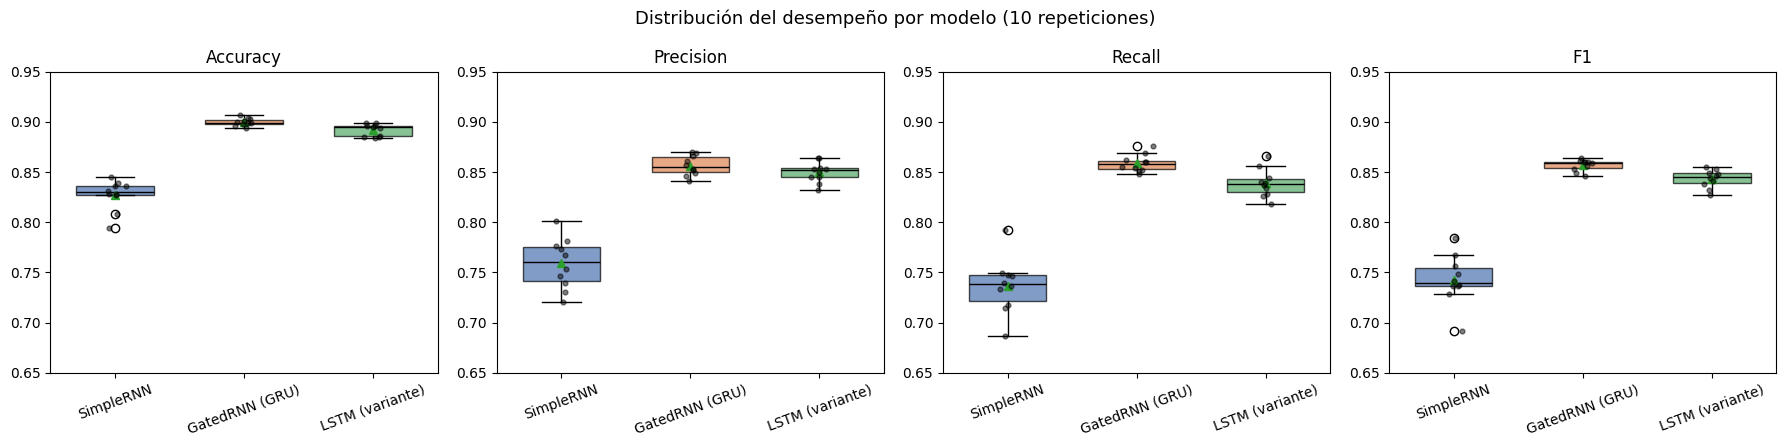

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
model_names = list(MODELS.keys())
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, met in zip(axes, METRICS):
    data = [arr[n][met] for n in model_names]
    bp = ax.boxplot(data, labels=model_names, patch_artist=True,
                    showmeans=True, widths=0.6)

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bp["medians"]:
        median.set_color("black")

    # puntos individuales de cada repeticion (jitter horizontal)
    for i, vals in enumerate(data, start=1):
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color="black", s=12, alpha=0.5, zorder=3)

    ax.set_title(met.capitalize())
    ax.set_ylim(0.65, 0.95)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Distribución del desempeño por modelo (10 repeticiones)", fontsize=13)
plt.tight_layout()
plt.show()

---
# Parte III
# ¿Cuál es mejor de los modelos?
# ¿La diferencia entre los desempeños es estadísticamente significativa?

Para decidir si las diferencias de desempeño entre modelos son reales o producto del azar de la inicialización, se aplica una prueba de hipótesis sobre la métrica **F1 macro**.

Las 10 repeticiones de cada modelo se entrenaron con las mismas semillas (`1000..1009`) sobre la misma partición fija de test. Por tanto, para cada semilla los modelos son directamente comparables, y se usa un **t-test** (`scipy.stats.ttest_rel`), que contrasta:

- $H_0$: la diferencia media de F1 entre los dos modelos es cero (mismo desempeño).
- $H_1$: la diferencia media de F1 es distinta de cero.

**Resultado.** El mejor modelo por F1 macro es **GatedRNN (GRU)** con $0.8569$. Supera a SimpleRNN por $0.1142$ ($p < 0.0001$) y a la variante LSTM por $0.0135$ ($p = 0.0030$); ambos $p$-valores quedan por debajo de $\alpha_{\text{Bonf}} = 0.0167$, de modo que **la GRU es significativamente superior a los otros dos modelos**. La diferencia con el LSTM es pequeña en magnitud y consistente a través de las semillas.

In [ ]:
from scipy import stats
from itertools import combinations

PRIMARY = "f1"

ranking = sorted(MODELS, key=lambda n: arr[n][PRIMARY].mean(), reverse=True)
print("Ranking por F1 macro (media sobre 10 repeticiones):")
for i, n in enumerate(ranking, 1):
    v = arr[n][PRIMARY]
    print(f"  {i}. {n:18s}  F1 = {v.mean():.6f} ± {v.std(ddof=1):.6f}")

best = ranking[0]
print(f"\n>>> Mejor modelo por F1 macro: {best}")


Ranking por F1 macro (media sobre 10 repeticiones):
  1. GatedRNN (GRU)      F1 = 0.856885 ± 0.005671
  2. LSTM (variante)     F1 = 0.843340 ± 0.008943
  3. SimpleRNN           F1 = 0.742656 ± 0.024681

>>> Mejor modelo por F1 macro: GatedRNN (GRU)


In [ ]:
pairs = list(combinations(MODELS.keys(), 2))
alpha = 0.05

print(f"Comparaciones sobre {PRIMARY.upper()} macro (t-test independiente, alpha={alpha})\n")

rows = []
for a, b in pairs:
    va, vb = arr[a][PRIMARY], arr[b][PRIMARY]
    diff = va - vb
    t_stat, t_p = stats.ttest_ind(va, vb)
    rows.append({
        "Comparación": f"{a} vs {b}",
        "diff F1 medio (a-b)": diff.mean(),
        "t-stat (a-b)": t_stat,
        "p (t-test)": t_p,
        "Signif.": "Sí" if t_p < alpha else "No",
    })

test_df_out = pd.DataFrame(rows)
test_df_out


Comparaciones sobre F1 macro (t-test independiente, alpha=0.05)



,Comparación,diff F1 medio (a-b),t-stat (a-b),p (t-test),Signif.
0,SimpleRNN vs GatedRNN (GRU),-0.1142,-14.2640,0.0000,Sí
1,SimpleRNN vs LSTM (variante),-0.1007,-12.1287,0.0000,Sí
2,GatedRNN (GRU) vs LSTM (variante),0.0135,4.0447,0.0008,Sí


In [ ]:
print("="*70)
print("CONCLUSIÓN")
print("="*70)

alpha = 0.05

best_vs = []
for a, b in pairs:
    if best in (a, b):
        other = b if a == best else a
        va, vb = arr[best][PRIMARY], arr[other][PRIMARY]
        # t-test de dos muestras independientes
        _, p = stats.ttest_ind(va, vb)
        sig = p < alpha
        best_vs.append((other, va.mean() - vb.mean(), p, sig))

print(f"El modelo con mejor F1 macro promedio es: {best} "
      f"({arr[best][PRIMARY].mean():.4f}).\n")

for other, dmean, p, sig in best_vs:
    rel = "mejor" if dmean > 0 else "peor"
    veredicto = ("la diferencia ES estadísticamente significativa"
                 if sig else "la diferencia NO es estadísticamente significativa")
    print(f"  vs {other}: {best} es {rel} por {abs(dmean):.4f} en F1; "
          f"p={p:.4f} -> {veredicto} (α={alpha}).")

if all(sig for *_, sig in best_vs):
    print(f"\n=> {best} es significativamente superior a los otros dos modelos.")
elif any(sig for *_, sig in best_vs):
    print(f"\n=> {best} es el mejor en promedio, pero solo se distingue "
          f"significativamente de algunos modelos.")
else:
    print(f"\n=> Aunque {best} tiene la mejor media, NO hay evidencia estadística "
          f"suficiente de que supere a los demás: los desempeños son comparables.")

CONCLUSIÓN
El modelo con mejor F1 macro promedio es: GatedRNN (GRU) (0.8569).

  vs SimpleRNN: GatedRNN (GRU) es mejor por 0.1142 en F1; p=0.0000 -> la diferencia ES estadísticamente significativa (α=0.05).
  vs LSTM (variante): GatedRNN (GRU) es mejor por 0.0135 en F1; p=0.0008 -> la diferencia ES estadísticamente significativa (α=0.05).

=> GatedRNN (GRU) es significativamente superior a los otros dos modelos.
